# Importing Necessary Libraries and Uploading the Files

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity



df_links = pd.read_csv("/content/links.csv")     # movieID, imdbID and tmdbID
df_movies = pd.read_csv("/content/movies.csv")   # movieID, movie title, genre
df_ratings = pd.read_csv("/content/ratings.csv") # userID, movieID, rating, time stamp
df_tags = pd.read_csv("/content/tags.csv")       # userID, movieID, tag, time stamp

In [ ]:
df_links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
df_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
df_tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


# 1. Checking the Data

In [ ]:
# 1. Basic Information
datasets = {
    "links": df_links,
    "movies": df_movies,
    "ratings": df_ratings,
    "tags": df_tags}

for name, df in datasets.items():
    print(f"\n-- {name.upper()}")

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    print("\nData types:")
    print(f"{df.dtypes}\n")


# 2. Summary Table
summary = pd.DataFrame({
    "dataset": ["links", "movies", "ratings", "tags"],
    "rows": [
        len(df_links),
        len(df_movies),
        len(df_ratings),
        len(df_tags)],

    "columns": [
        df_links.shape[1],
        df_movies.shape[1],
        df_ratings.shape[1],
        df_tags.shape[1]],

    "missing_values": [
        df_links.isna().sum().sum(),
        df_movies.isna().sum().sum(),
        df_ratings.isna().sum().sum(),
        df_tags.isna().sum().sum()],

    "duplicated_rows": [
        df_links.duplicated().sum(),
        df_movies.duplicated().sum(),
        df_ratings.duplicated().sum(),
        df_tags.duplicated().sum()]})

print("\nSummary Table:")
display(summary)


# 3. Check IDs Format
bad_movieIds_movies = ((df_movies["movieId"] <= 0) | (df_movies["movieId"] % 1 != 0)).sum()

bad_movieIds_ratings = ((df_ratings["movieId"] <= 0) | (df_ratings["movieId"] % 1 != 0)).sum()
bad_userIds_ratings = ((df_ratings["userId"] <= 0) | (df_ratings["userId"] % 1 != 0)).sum()

bad_movieIds_tags = ((df_tags["movieId"] <= 0) | (df_tags["movieId"] % 1 != 0)).sum()
bad_userIds_tags = ((df_tags["userId"] <= 0) | (df_tags["userId"] % 1 != 0)).sum()

bad_movieIds_links = ((df_links["movieId"] <= 0) | (df_links["movieId"] % 1 != 0)).sum()


print("\nBad movieIds in movies:", bad_movieIds_movies)

print("Bad movieIds in ratings:", bad_movieIds_ratings)
print("Bad userIds in ratings:", bad_userIds_ratings)

print("Bad movieIds in tags:", bad_movieIds_tags)
print("Bad userIds in tags:", bad_userIds_tags)

print("Bad movieIds in links:", bad_movieIds_links)


# 4. Check Ratings Format
allowed_ratings = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

bad_ratings = df_ratings[~df_ratings["rating"].isin(allowed_ratings)]

print("\nNumber of invalid ratings:", len(bad_ratings))


# 5. Check if Movies IDs Matches Between Tables
movies_ids = set(df_movies["movieId"])
ratings_movie_ids = set(df_ratings["movieId"])
tags_movie_ids = set(df_tags["movieId"])
links_movie_ids = set(df_links["movieId"])

rated_movies_not_in_movies = ratings_movie_ids - movies_ids
tagged_movies_not_in_movies = tags_movie_ids - movies_ids
linked_movies_not_in_movies = links_movie_ids - movies_ids

print("\nRated movieIds not in movies table:", len(rated_movies_not_in_movies))
print("Tagged movieIds not in movies table:", len(tagged_movies_not_in_movies))
print("Linked movieIds not in movies table:", len(linked_movies_not_in_movies))

movies_without_ratings = movies_ids - ratings_movie_ids
movies_without_tags = movies_ids - tags_movie_ids
movies_without_links = movies_ids - links_movie_ids

print("\nMovies without ratings:", len(movies_without_ratings))
print("Movies without tags:", len(movies_without_tags))
print("Movies without links:", len(movies_without_links))


-- LINKS
Shape: (9742, 3)
Columns: ['movieId', 'imdbId', 'tmdbId']

Data types:
movieId      int64
imdbId       int64
tmdbId     float64
dtype: object


-- MOVIES
Shape: (9742, 3)
Columns: ['movieId', 'title', 'genres']

Data types:
movieId     int64
title      object
genres     object
dtype: object


-- RATINGS
Shape: (100836, 4)
Columns: ['userId', 'movieId', 'rating', 'timestamp']

Data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object


-- TAGS
Shape: (3683, 4)
Columns: ['userId', 'movieId', 'tag', 'timestamp']

Data types:
userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object


Summary Table:


,dataset,rows,columns,missing_values,duplicated_rows
0,links,9742,3,8,0
1,movies,9742,3,0,0
2,ratings,100836,4,0,0
3,tags,3683,4,0,0



Bad movieIds in movies: 0
Bad movieIds in ratings: 0
Bad userIds in ratings: 0
Bad movieIds in tags: 0
Bad userIds in tags: 0
Bad movieIds in links: 0

Number of invalid ratings: 0

Rated movieIds not in movies table: 0
Tagged movieIds not in movies table: 0
Linked movieIds not in movies table: 0

Movies without ratings: 18
Movies without tags: 8170
Movies without links: 0


## 1.1 Delete Movies Without Ratings

In [ ]:
# Movie Ids that have at least one rating:
rated_movie_ids = set(df_ratings["movieId"])

# Only rated movies:
df_movies_rated = df_movies[df_movies["movieId"].isin(rated_movie_ids)]

df_movies = df_movies[df_movies["movieId"].isin(rated_movie_ids)].reset_index(drop=True)


# 2. Visualization of the Data


### Histogram:

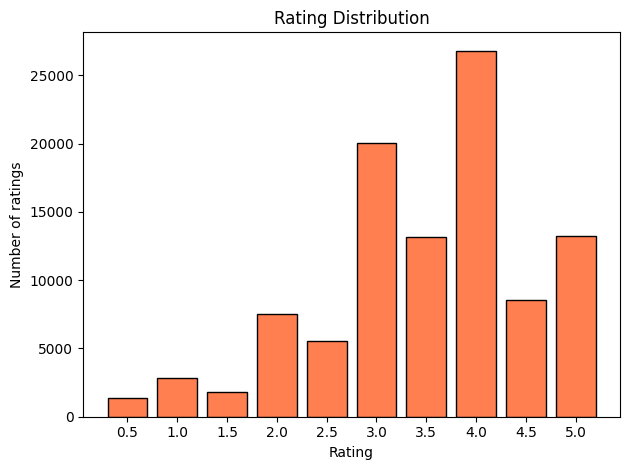

In [ ]:
rating_counts = df_ratings["rating"].value_counts().sort_index()

# Histogram of ratings densities:

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values, edgecolor = 'black', color = 'coral'
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of ratings")

plt.tight_layout()
plt.show()


### Correlation Matrix:

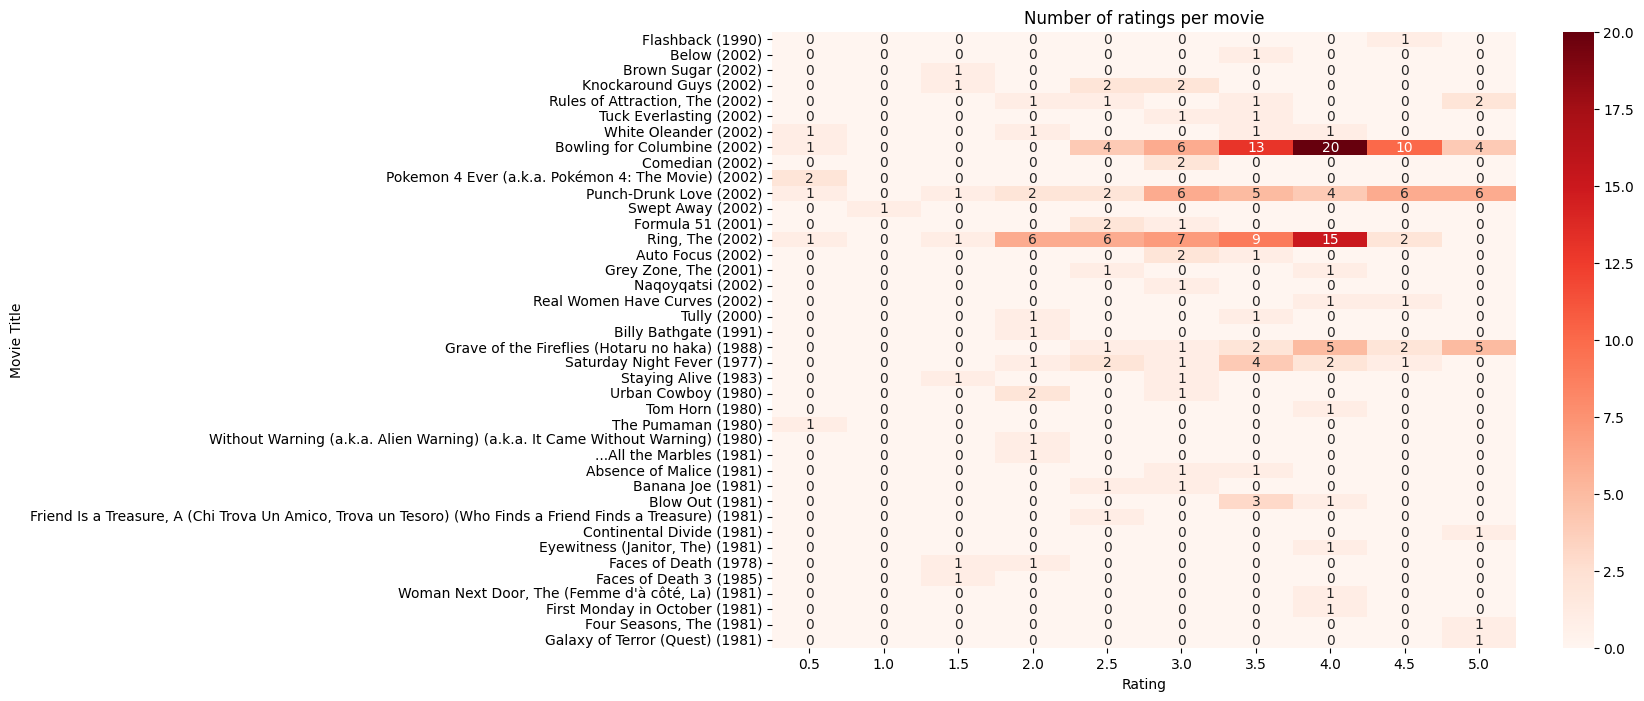

In [ ]:
# Correlation Matrix:
import seaborn as sns

rating_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

rating_matrix = pd.crosstab(
    df_ratings["movieId"],
    df_ratings["rating"])

rating_matrix_top = rating_matrix[4000:4040]

# Create dictionary: movieId -> title:
movie_titles = df_movies.set_index("movieId")["title"]

# Replace movieId index with movie titles:
rating_matrix_top.index = rating_matrix_top.index.map(movie_titles)

plt.figure(figsize=(12, 8))
sns.heatmap(rating_matrix_top, cmap = "Reds", annot = True)
plt.xlabel("Rating")
plt.ylabel("Movie Title")
plt.title("Number of ratings per movie")
plt.show()

### Averge rating by genre:

In [ ]:
# Merge ratings with movies
ratings_movies = df_ratings.merge(df_movies, on="movieId", how="left")

# Split genres
ratings_movies["genres"] = ratings_movies["genres"].str.split("|")

# Put each genre in a separate row
ratings_genres = ratings_movies.explode("genres")

# Remove movies without genre information
ratings_genres = ratings_genres[ratings_genres["genres"] != "(no genres listed)"]

# Calculate average rating by genre
average_rating_by_genre = (
    ratings_genres
    .groupby("genres")
    .agg(
        average_rating=("rating", "mean"),
        number_of_ratings=("rating", "count"),
        number_of_movies=("movieId", "nunique")
    )
    .sort_values("average_rating", ascending=False))

print(average_rating_by_genre)

             average_rating  number_of_ratings  number_of_movies
genres                                                          
Film-Noir          3.920115                870                85
War                3.808294               4859               381
Documentary        3.797785               1219               438
Crime              3.658294              16681              1196
Drama              3.656184              41928              4349
Mystery            3.632460               7674               573
Animation          3.629937               6988               610
IMAX               3.618335               4145               158
Western            3.583938               1930               167
Musical            3.563678               4138               333
Adventure          3.508609              24161              1262
Romance            3.506511              18124              1591
Thriller           3.493706              26452              1889
Fantasy            3.4910

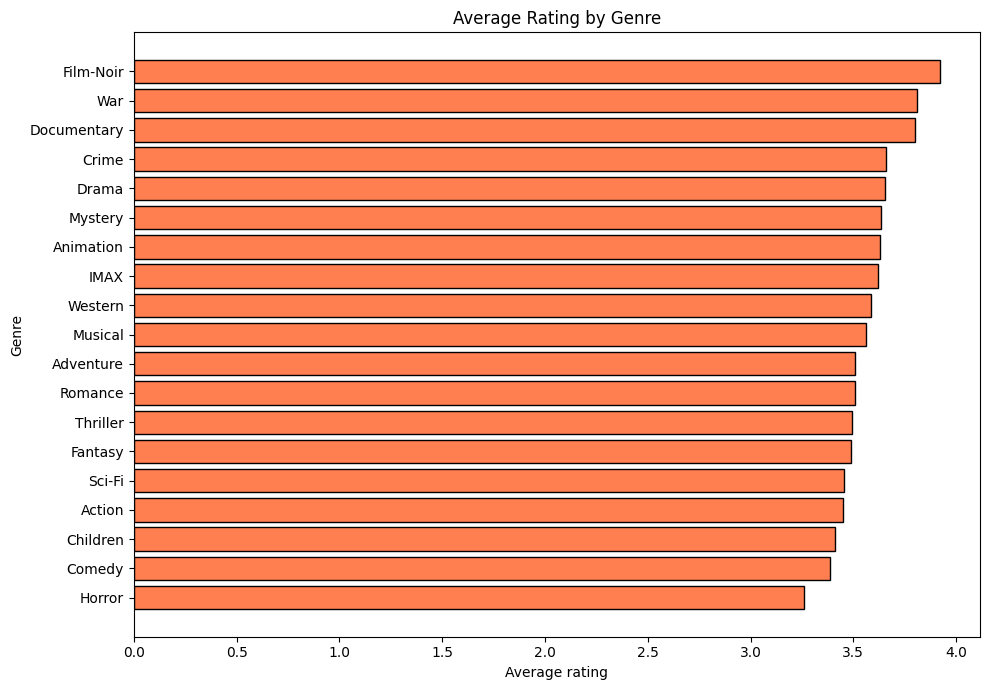

In [ ]:
average_rating_plot = average_rating_by_genre.sort_values("average_rating")

plt.figure(figsize=(10, 7))
plt.barh(average_rating_plot.index, average_rating_plot["average_rating"], color = 'coral', edgecolor = 'black')
plt.xlabel("Average rating")
plt.ylabel("Genre")
plt.title("Average Rating by Genre")
plt.xlabel("Average rating")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

### Popularity vs average rating scatter plot:

In [ ]:
# Calculate popularity and average rating for each movie
movie_stats = (
    df_ratings
    .groupby("movieId")
    .agg(
        number_of_ratings=("rating", "count"),
        average_rating=("rating", "mean")).reset_index())

# Add movie titles
movie_stats = movie_stats.merge(df_movies, on="movieId", how="left")

print(movie_stats.head())

   movieId  number_of_ratings  average_rating  \
0        1                215        3.920930   
1        2                110        3.431818   
2        3                 52        3.259615   
3        4                  7        2.357143   
4        5                 49        3.071429   

                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


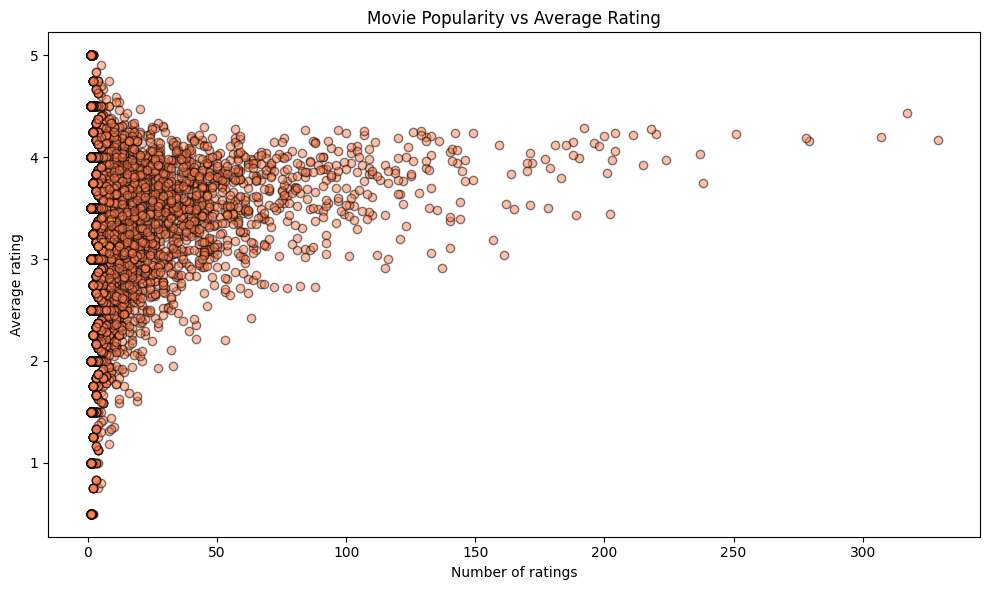

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    movie_stats["number_of_ratings"],
    movie_stats["average_rating"],
    alpha=0.5, color = 'coral', edgecolors = 'black'
)

plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of ratings")
plt.ylabel("Average rating")

plt.tight_layout()
plt.show()

# **KNN Recommendation System using Cosine Similarity**

# **1. Load and prepare the data**


In [ ]:
# Load movies and ratings data
movies = pd.read_csv("/content/movies.csv", usecols = ["movieId", "title"])
ratings = pd.read_csv("/content/ratings.csv", usecols = ["userId", "movieId", "rating"])

# Merge both datasets into one dataframe
merged_df = pd.merge(movies, ratings, on="movieId")
merged_df.head()

,movieId,title,userId,rating
0,1,Toy Story (1995),1,4.0
1,1,Toy Story (1995),5,4.0
2,1,Toy Story (1995),7,4.5
3,1,Toy Story (1995),15,2.5
4,1,Toy Story (1995),17,4.5


### **1.1 Split users into train and test users**

*   **df_train** - 80% of users (our training database)

*   **df_test** - 20% of users (simulate potential clients/users)

Function that finds the closest neighbours and recommendations should work on a matrix that includes test users but without some of the ratings.

Then we test the model comparing our predictions to the other ratings earlier excluded.


In [ ]:
random.seed(10)

all_users = sorted(merged_df["userId"].unique())

train_size = int(0.8 * len(all_users))
train_users = random.sample(all_users, train_size)

test_users = np.array([user for user in all_users if user not in train_users],
                      dtype = np.int64)

print("Number of users:", len(all_users), "| Train users:", len(train_users), "| Test users:", len(test_users))


Number of users: 610 | Train users: 488 | Test users: 122


### **1.2 Hide part of test users' ratings**
*   **observed_df** – used to build the recommendation matrix
*   **hidden_df** – used only for evaluation




In [ ]:
observed_df = merged_df.copy()
hidden_df = merged_df.copy()

hidden_fraction = 0.3

for user in test_users:

  user_ratings = merged_df[merged_df["userId"] == user]
  num_hidden = int(hidden_fraction * len(user_ratings))

  if num_hidden == 0:
        continue

  random.seed(20 + int(user))

  hidden_indices = random.sample(list(user_ratings.index), num_hidden)

  # Save hidden ratings for evaluation
  hidden_df = pd.concat(
        [hidden_df, observed_df.loc[hidden_indices]],
        ignore_index=True)

  # Remove hidden ratings from observed data
  observed_df = observed_df.drop(hidden_indices)

print("Observed data shape:", observed_df.shape)
print("Hidden evaluation data shape:", hidden_df.shape)

Observed data shape: (94591, 4)
Hidden evaluation data shape: (107081, 4)


### **1.3 Build user-movie matrix**

* Rows = users
* Columns = movie IDs
* Values = ratings




In [ ]:
user_movie_matrix = observed_df.pivot_table(
    index = "userId",
    columns = "movieId",
    values = "rating")

user_movie_matrix = user_movie_matrix.fillna(0)

user_movie_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,2.5,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **1.4 Compute cosin similarity**

This calculates how similar each user is to every other user based on their movie ratings.

In [ ]:
similarity_matrix = cosine_similarity(user_movie_matrix)
print(similarity_matrix)

[[1.         0.01609645 0.02082291 ... 0.20777494 0.09997925 0.12659254]
 [0.01609645 1.         0.         ... 0.04328848 0.0275654  0.09263182]
 [0.02082291 0.         1.         ... 0.01056943 0.         0.0140131 ]
 ...
 [0.20777494 0.04328848 0.01056943 ... 1.         0.12077357 0.24858142]
 [0.09997925 0.0275654  0.         ... 0.12077357 1.         0.04483682]
 [0.12659254 0.09263182 0.0140131  ... 0.24858142 0.04483682 1.        ]]


### **1.5 Helper function**

In [ ]:
movie_id_to_title = movies.set_index("movieId")["title"].to_dict()

def movie_ids_with_titles(movie_ids):
    return [
        f"{movie_id} - {movie_id_to_title.get(movie_id, 'Unknown title')}"
        for movie_id in movie_ids]

# **2. Function that finds closest neighbours**

In [ ]:
def find_neighbours(user_id, ratings_matrix, similarity_matrix, top_n):

    if user_id not in ratings_matrix.index:
        raise ValueError(f"User {user_id} is not present in the ratings matrix.")

    user_index = ratings_matrix.index.get_loc(user_id)
    user_similarity = similarity_matrix[user_index]

    sorted_similarity_indices = np.argsort(user_similarity)[::-1][1:top_n+1]

    closest_neighbours = ratings_matrix.index[sorted_similarity_indices]

    return list(closest_neighbours)


In [ ]:
random.seed(13)
example_user = random.choice(test_users)

result = find_neighbours(example_user, user_movie_matrix, similarity_matrix, 5)
print(f"Closest neighbours of user {example_user}:", result)

Closest neighbours of user 125: [249, 212, 247, 305, 560]


# **3. Recommendation function**

In [ ]:
def find_recommendations(user_id, similarity_matrix, ratings_matrix, top_n, rec_n = 5):

    closest_neighbours = find_neighbours(user_id, ratings_matrix, similarity_matrix, top_n)

    neighbours_ratings = ratings_matrix.loc[closest_neighbours]

    average_ratings = neighbours_ratings.replace(0, np.nan).mean()

    already_rated = ratings_matrix.loc[user_id] > 0
    average_ratings = average_ratings[~already_rated]

    all_movie_recs = average_ratings.dropna().sort_values(ascending = False)

    top_movie_recs = all_movie_recs.head(rec_n)

    return top_movie_recs, all_movie_recs


In [ ]:
result = find_recommendations(example_user, similarity_matrix, user_movie_matrix, 5)[0]
movies_ids = result.index.to_list()
titles = movie_ids_with_titles(movies_ids)

result_df = pd.DataFrame({
    "movieId": movies_ids,
    "title": titles,
    "rating": result.values
})

result_df

,movieId,title,rating
0,187593,187593 - Deadpool 2 (2018),5.0
1,357,357 - Four Weddings and a Funeral (1994),5.0
2,140627,140627 - Battle For Sevastopol (2015),5.0
3,431,431 - Carlito's Way (1993),5.0
4,105585,105585 - Machete Kills (Machete 2) (2013),5.0


#**4. Evaluated recommendation function**

In [ ]:
def find_recommendations_eval(user_id, similarity_matrix, ratings_matrix, top_n):

    closest_neighbours = find_neighbours(user_id, ratings_matrix, similarity_matrix, top_n)

    user_ratings = hidden_df[hidden_df["userId"] == user_id]
    user_rated_movies = [
        movie_id for movie_id in user_ratings["movieId"].tolist()
        if movie_id in ratings_matrix.columns]

    if len(user_rated_movies) == 0:
        return pd.Series(dtype=float)

    neighbours_ratings = ratings_matrix.loc[closest_neighbours, user_rated_movies]

    neighbours_ratings = neighbours_ratings.replace(0, np.nan)

    neigh_trans = neighbours_ratings.transpose()
    neigh_trans["mean"] = neigh_trans.mean(axis=1, skipna = True)

    average_ratings = neigh_trans["mean"]
    return average_ratings


result = find_recommendations_eval(example_user, similarity_matrix, user_movie_matrix, 5)
print(result.index.to_list())
result


[2, 81, 110, 208, 223, 288, 296, 318, 337, 356, 501, 522, 555, 589, 593, 608, 858, 1034, 1084, 1120, 1193, 1206, 1210, 1215, 1221, 1240, 1261, 1265, 1270, 1285, 1580, 1590, 1625, 1726, 1732, 1844, 1873, 2318, 2321, 2387, 2571, 2596, 2600, 2657, 2692, 2843, 2858, 2918, 2959, 3052, 3083, 3147, 3342, 3553, 3949, 4022, 4082, 4226, 4246, 4643, 4738, 4848, 4864, 4878, 4973, 4979, 4995, 5088, 5218, 5219, 5459, 5617, 5816, 5903, 5956, 6016, 6502, 6539, 6711, 6874, 6902, 6952, 7008, 7022, 7254, 7265, 7361, 7371, 7438, 8254, 8360, 8368, 8376, 8665, 8807, 8957, 9010, 26680, 26681, 27022, 27482, 27773, 27788, 32460, 33145, 33201, 33615, 33794, 35836, 36401, 40148, 42632, 43836, 44191, 44195, 44974, 45440, 45722, 47491, 47997, 48385, 48516, 48774, 50842, 52328, 52973, 53125, 54190, 54286, 54503, 55247, 55278, 55820, 55908, 56174, 58301, 58559, 58998, 59315, 59784, 60069, 60072, 60684, 60756, 60950, 61323, 62336, 62434, 62439, 63072, 65130, 65514, 65642, 67087, 67695, 68157, 68237, 68358, 68954, 695

,mean
movieId,
2,3.750000
81,NaN
110,4.333333
208,3.500000
223,3.666667
...,...
60950,NaN
137857,4.500000
59315,3.500000


# **5. Compare average ratings from the recommendation function with actual ratings for a test user**

In [ ]:
random.seed(12)

test_user1 = random.choice(test_users)

def compare_ratings(test_user, top_n, show_frame=False, verbose=False):

  test_result = find_recommendations_eval(test_user, similarity_matrix, user_movie_matrix, top_n).dropna()

  eval_df = test_result.reset_index()
  eval_df.columns = ["movieId", "Predicted rating"]

  true_ratings = hidden_df[hidden_df["userId"] == test_user][["movieId", "title", "rating"]]
  eval_df = eval_df.merge(true_ratings, on="movieId", how="inner")
  eval_df = eval_df.rename(columns={"title": "Title", "rating": "Actual rating"})
  eval_df = eval_df[["movieId", "Title", "Predicted rating", "Actual rating"]]

  eval_df["errors"] = eval_df["Predicted rating"] - eval_df["Actual rating"]
  mean_error = eval_df["errors"].abs().mean()

  if verbose == True:
    print("Test user:", test_user)
    print("Mean error:", mean_error)
  if show_frame == True:
    display(eval_df)
  return test_user, mean_error

compare_ratings(test_user1, 5, True)

random.seed(10)

test_user_sample = random.sample(list(test_users), min(30, len(test_users)))

list_of_errors = []
for test_user in test_user_sample:
  mean_error = compare_ratings(test_user, 5)[1]
  list_of_errors.append(mean_error)

max_err = max([abs(err) for err in list_of_errors])
avg_err = np.mean(list_of_errors)
print("\nMax error:", max_err)
print("Average error:", avg_err, "\n")

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
max_errs = []
avg_errs = []

for n in n_values:
  random.seed(10)
  test_user_sample = random.sample(list(test_users), min(30, len(test_users)))

  list_of_errors = []
  for test_user in test_user_sample:
    mean_error = compare_ratings(test_user, n)[1]
    list_of_errors.append(mean_error)

  max_err = max([abs(err) for err in list_of_errors])
  avg_err = np.mean(list_of_errors)

  max_errs.append(max_err)
  avg_errs.append(avg_err)

df_n_values = pd.DataFrame({
    "n_values":n_values,
    "max error":max_errs,
    "average error":avg_errs
})

df_n_values


,movieId,Title,Predicted rating,Actual rating,errors
0,783,"Hunchback of Notre Dame, The (1996)",3.000000,2.5,0.500000
1,1381,Grease 2 (1982),3.000000,3.0,0.000000
2,2329,American History X (1998),4.333333,4.0,0.333333
3,2329,American History X (1998),4.333333,4.0,0.333333
4,2694,Big Daddy (1999),5.000000,3.0,2.000000
5,2694,Big Daddy (1999),5.000000,3.0,2.000000
6,2858,American Beauty (1999),3.333333,3.5,-0.166667
7,3897,Almost Famous (2000),4.000000,3.5,0.500000
8,8368,Harry Potter and the Prisoner of Azkaban (2004),3.500000,4.0,-0.500000
9,8368,Harry Potter and the Prisoner of Azkaban (2004),3.500000,4.0,-0.500000



Max error: 2.084166666666667
Average error: 0.9464206482906109 



,n_values,max error,average error
0,1,1.875000,0.902329
1,2,2.016667,0.899866
2,3,1.818910,0.934967
3,4,2.028509,0.929325
4,5,2.084167,0.946421
5,6,2.219841,0.929407
6,7,2.057810,0.915861
7,8,2.042095,0.908612
8,9,2.032810,0.898710
9,10,2.096689,0.914560


# **6. Visualize accuracy testing**

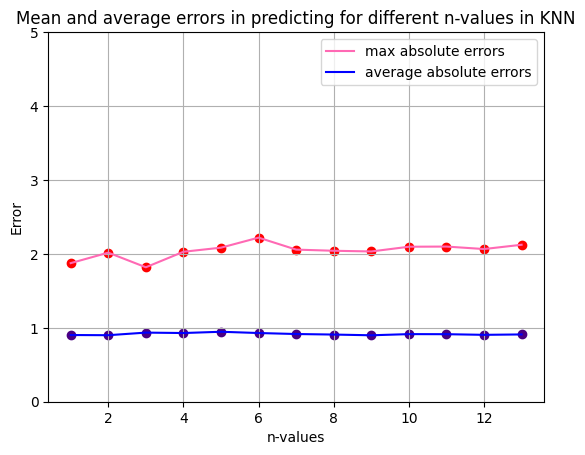

In [ ]:
plt.scatter(n_values, max_errs, color = 'red')
plt.plot(n_values, max_errs, color = 'hotpink', label = "max absolute errors")

plt.scatter(n_values, avg_errs, color = 'indigo')
plt.plot(n_values, avg_errs, color = 'blue', label = "average absolute errors")

plt.ylim((0, 5))
plt.ylabel('Error')
plt.xlabel('n-values')
plt.grid()
plt.legend()
plt.title("Mean and average errors in predicting for different n-values in KNN")
plt.show()

# **7. Evaluating the KNN model**

In [ ]:
movie_id_to_title = movies.set_index("movieId")["title"].to_dict()

def get_titles(movie_ids):
    return [
        movie_id_to_title.get(movie_id, "Unknown title")
        for movie_id in movie_ids]

In [ ]:
def evaluate_model(user_id, similarity_matrix, ratings_matrix, top_n, relevant_rating=0.0):

    relevant_movies = set(
        hidden_df[(hidden_df["userId"] == user_id) &
         (hidden_df["rating"] > relevant_rating)]["movieId"])

    print("Relevant hidden movies:", relevant_movies)
    print("num rel:", len(relevant_movies))

    top_recommendations, all_recommendations = find_recommendations(
        user_id, similarity_matrix, ratings_matrix, 5, rec_n = top_n)

    recommended_movies = set(top_recommendations.index)

    print("\nRecommended movies:", recommended_movies)

    for title in get_titles(recommended_movies):
        print(title)

    print("len:", len(all_recommendations))

    hits = recommended_movies.intersection(relevant_movies)
    print("Hits:", hits)

    # PRECISION
    # Proportion of recommended movies that are actually relevant to the user.
    precision = len(hits) / len(recommended_movies) if len(recommended_movies) > 0 else 0

    # RECALL
    # Proportion of user's relevant movies that were included in the recommendations.
    recall = len(hits) / len(relevant_movies) if len(relevant_movies) > 0 else 0

    f1_score = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    return precision, recall, f1_score


precision, recall, f1_score = evaluate_model(test_users[min(100, len(test_users)-1)], similarity_matrix, user_movie_matrix, 5)

print("precision:", precision)
print("recall:", recall)
print("f1_score:", f1_score)

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]

precisions = []
recalls = []
f1_scores = []

for n in n_values:
    precision, recall, f1_score = evaluate_model(example_user, similarity_matrix, user_movie_matrix, n)

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1_score)

    print("----------------")
    print(n)
    print("precision:", precision)
    print("recall:", recall)
    print("f1_score:", f1_score)

max_precision = max(precisions)
max_recall = max(recalls)
max_f1 = max(f1_scores)

max_precision_n = n_values[precisions.index(max_precision)]
max_recall_n = n_values[recalls.index(max_recall)]
max_f1_n = n_values[f1_scores.index(max_f1)]

print("\nn with max precision:", max_precision_n, "| max precision:", max_precision)
print("n with max recall:", max_recall_n, "| max recall:", max_recall)
print("n with max f1 score:", max_f1_n, "| max f1 score:", max_f1)


Relevant hidden movies: {54272, 97921, 49286, 180231, 2953, 6539, 1682, 104211, 4246, 45720, 7451, 2716, 6942, 69406, 4896, 27808, 106782, 106918, 81834, 3247, 86833, 4018, 5299, 81845, 104374, 5816, 4025, 50872, 317, 88125, 31685, 91077, 64969, 586, 129354, 170697, 1485, 65230, 140110, 8529, 4306, 95441, 69844, 597, 88405, 171867, 5218, 356, 6373, 104, 30825, 88810, 3948, 367, 2671, 1265, 34162, 40815, 54001, 63859, 69757, 1911, 1784, 7293}
num rel: 64

Recommended movies: {128520, 1704, 111759, 117590, 122904}
The Wedding Ringer (2015)
Good Will Hunting (1997)
Edge of Tomorrow (2014)
Horrible Bosses 2 (2014)
Deadpool (2016)
len: 304
Hits: set()
precision: 0.0
recall: 0.0
f1_score: 0
Relevant hidden movies: {2, 122882, 69640, 122890, 122892, 122904, 122918, 122922, 26680, 26681, 8254, 88129, 88140, 81, 141408, 133217, 88163, 92259, 65642, 110, 67695, 127096, 139385, 69757, 4226, 151695, 4246, 116897, 8360, 86190, 161966, 8368, 108727, 8376, 84152, 208, 75985, 127198, 223, 127202, 1415

# **SSE Method**

In [ ]:
def find_similar_users(df_ratings, target_user_id=None, min_overlap_pct=0.3, top_n=3, random_state=None):
    """
    The function selects a random user or uses the given target_user_id.
    Then it finds users who rated at least a selected percentage of the same movies.
    Rating similarity is calculated using SSE.
    """

    rng = np.random.default_rng(random_state)

    # Random user selection if no specific user was given.
    if target_user_id is None:
        target_user_id = rng.choice(df_ratings["userId"].unique())

    # Ratings of the selected user.
    target_ratings = df_ratings[df_ratings["userId"] == target_user_id][["movieId", "rating"]]
    target_ratings = target_ratings.rename(columns={"rating": "target_rating"})

    target_movie_count = len(target_ratings)

    if target_movie_count == 0:
        raise ValueError("Chosen user doesn't have any ratings")

    # Ratings of other users.
    other_ratings = df_ratings[df_ratings["userId"] != target_user_id][["userId", "movieId", "rating"]]

    # Keep only common movies: rated by the target user and by other users.
    common_ratings = other_ratings.merge(target_ratings, on="movieId")

    if common_ratings.empty:
        return target_user_id, pd.DataFrame(), pd.DataFrame()

    # Calculate squared error for every common rating.
    common_ratings["squared_error"] = (common_ratings["rating"] - common_ratings["target_rating"]) ** 2

    # Group by users.
    similarity = common_ratings.groupby("userId").agg(
        common_movies=("movieId", "nunique"),
        sse=("squared_error", "sum")
    ).reset_index()

    # Percentage of common movies compared to the number of movies rated by the target user.
    similarity["overlap_pct"] = similarity["common_movies"] / target_movie_count

    # Calculate SSE per common movie so users with more common movies are not punished too strongly.
    similarity["sse_per_movie"] = similarity["sse"] / similarity["common_movies"]

    # Filter users who have enough common movies.
    similarity = similarity[similarity["overlap_pct"] >= min_overlap_pct]

    # Convert SSE into a similarity weight. Lower SSE means higher similarity.
    similarity["similarity"] = 1 / (1 + similarity["sse_per_movie"])

    # Sorting: the smallest SSE per movie means the most similar ratings.
    similarity = similarity.sort_values(
        by=["sse_per_movie", "sse", "common_movies"],
        ascending=[True, True, False]
    )

    top_similar_users = similarity.head(top_n)

    return target_user_id, top_similar_users, similarity

In [ ]:
target_user_id, top_similar_users, all_similar_users = find_similar_users(
    df_ratings,
    target_user_id=None,      # None means a random user.
    min_overlap_pct=0.3,      # For example: minimum 30% of common movies.
    top_n=3,
    random_state=42
)

print("User:", target_user_id)
print("Similar users:")
print(top_similar_users)

User: 55
Similar users:
     userId  common_movies    sse  overlap_pct  sse_per_movie  similarity
308     553              8   5.50         0.32       0.687500    0.592593
13       18             11  10.00         0.44       0.909091    0.523810
313     561             10  12.75         0.40       1.275000    0.439560


In [ ]:
def recommend_movies(df_ratings, df_movies, target_user_id, similar_users, min_rating=4.0, top_n=10, min_similar_ratings=1):
    """
    The function recommends movies based on ratings from similar users.
    It recommends movies that the target user has not rated yet,
    but similar users rated highly.
    """

    if similar_users.empty:
        return pd.DataFrame(columns=["movieId", "title", "genres", "avg_rating", "predicted_rating", "n_similar_users"])

    # Movies already rated by the target user.
    target_seen_movies = set(
        df_ratings[df_ratings["userId"] == target_user_id]["movieId"]
    )

    similar_user_ids = similar_users["userId"].tolist()

    # Ratings given by similar users.
    candidate_ratings = df_ratings[
        (df_ratings["userId"].isin(similar_user_ids)) &
        (~df_ratings["movieId"].isin(target_seen_movies))
    ].copy()

    if candidate_ratings.empty:
        return pd.DataFrame(columns=["movieId", "title", "genres", "avg_rating", "predicted_rating", "n_similar_users"])

    # Add information about user similarity.
    candidate_ratings = candidate_ratings.merge(
        similar_users[["userId", "sse_per_movie", "overlap_pct", "common_movies", "similarity"]],
        on="userId"
    )

    # Weight: the smaller the SSE error, the higher the user weight.
    candidate_ratings["weight"] = candidate_ratings["similarity"]

    # Weighted rating.
    candidate_ratings["weighted_rating"] = candidate_ratings["rating"] * candidate_ratings["weight"]

    # Group by movies.
    recommendations = candidate_ratings.groupby("movieId").agg(
        predicted_rating_sum=("weighted_rating", "sum"),
        total_weight=("weight", "sum"),
        avg_rating=("rating", "mean"),
        n_similar_users=("userId", "nunique")
    ).reset_index()

    # Predicted rating as a weighted average.
    recommendations["predicted_rating"] = (
        recommendations["predicted_rating_sum"] / recommendations["total_weight"]
    )

    # Keep movies highly rated by similar users.
    recommendations = recommendations[
        (recommendations["avg_rating"] >= min_rating) &
        (recommendations["n_similar_users"] >= min_similar_ratings)
    ]

    # Add movie titles and genres.
    recommendations = recommendations.merge(df_movies, on="movieId")

    # Sort the best recommendations.
    recommendations = recommendations.sort_values(
        by=["predicted_rating", "n_similar_users", "avg_rating"],
        ascending=[False, False, False]
    )

    return recommendations.head(top_n)

In [ ]:
recommendations = recommend_movies(
    df_ratings,
    df_movies,
    target_user_id,
    top_similar_users,
    min_rating=4.0,
    top_n=10,
    min_similar_ratings=1
)

print("Recommended movies for user:", target_user_id)
print(recommendations[["title", "genres", "avg_rating", "predicted_rating", "n_similar_users"]])

Recommended movies for user: 55
                                          title  \
19             Shawshank Redemption, The (1994)   
68               Godfather: Part II, The (1974)   
56                   Princess Bride, The (1987)   
78         Bridge on the River Kwai, The (1957)   
97                                  Jaws (1975)   
140  Ghostbusters (a.k.a. Ghost Busters) (1984)   
163                             Predator (1987)   
168          Big Trouble in Little China (1986)   
191                         Donnie Darko (2001)   
195                Royal Tenenbaums, The (2001)   

                                      genres  avg_rating  predicted_rating  \
19                               Crime|Drama         5.0               5.0   
68                               Crime|Drama         5.0               5.0   
56   Action|Adventure|Comedy|Fantasy|Romance         5.0               5.0   
78                       Adventure|Drama|War         5.0               5.0   
97              

# Evaluation: SSE and KNN comparison

This section uses a more reliable evaluation method. For every selected user, some of their ratings are hidden. The model uses the remaining ratings to find similar users and then predicts the hidden ratings. The methods are compared using MAE, RMSE and coverage.

In [ ]:
# Build a movieId-based user-item matrix for the evaluation section.
# Movie IDs are better than titles here because they are stable and faster to process.

user_item_matrix = df_ratings.pivot(index="userId", columns="movieId", values="rating").fillna(0.0)
user_ids = user_item_matrix.index.to_numpy()
movie_ids = user_item_matrix.columns.to_numpy()

user_id_to_position = {user_id: position for position, user_id in enumerate(user_ids)}
movie_id_to_position = {movie_id: position for position, movie_id in enumerate(movie_ids)}

user_item_values = user_item_matrix.to_numpy(dtype=float)
user_vector_norms = np.linalg.norm(user_item_values, axis=1)

In [ ]:
def split_user_ratings(df_ratings, user_id, test_size=0.2, random_state=42):
    """
    Hide part of one user's ratings for evaluation.
    The hidden part is the test set. The remaining ratings are the training set for this user.
    """

    user_ratings = df_ratings[df_ratings["userId"] == user_id]

    if len(user_ratings) < 5:
        raise ValueError("User has too few ratings for evaluation.")

    n_test = max(1, int(round(len(user_ratings) * test_size)))
    n_test = min(n_test, len(user_ratings) - 1)

    test_ratings = user_ratings.sample(n=n_test, random_state=random_state)
    train_target_ratings = user_ratings.drop(test_ratings.index)

    return train_target_ratings, test_ratings

In [ ]:
def sse_neighbours_for_evaluation(df_ratings, target_user_id, target_train_ratings, top_n=50, min_overlap_pct=0.02, min_common=2):
    """
    Find neighbours using SSE, but only with the target user's training ratings.
    Hidden test ratings are not used to find neighbours.
    """

    target = target_train_ratings[["movieId", "rating"]].rename(columns={"rating": "target_rating"})

    if len(target) == 0:
        return pd.DataFrame(columns=["userId", "common_movies", "sse", "overlap_pct", "sse_per_movie", "similarity"])

    common = df_ratings[df_ratings["userId"] != target_user_id][["userId", "movieId", "rating"]].merge(target, on="movieId")

    if common.empty:
        return pd.DataFrame(columns=["userId", "common_movies", "sse", "overlap_pct", "sse_per_movie", "similarity"])

    common["squared_error"] = (common["rating"] - common["target_rating"]) ** 2

    neighbours = common.groupby("userId").agg(
        common_movies=("movieId", "nunique"),
        sse=("squared_error", "sum")
    ).reset_index()

    neighbours["overlap_pct"] = neighbours["common_movies"] / len(target)
    neighbours["sse_per_movie"] = neighbours["sse"] / neighbours["common_movies"]

    neighbours = neighbours[
        (neighbours["common_movies"] >= min_common) &
        (neighbours["overlap_pct"] >= min_overlap_pct)
    ].copy()

    neighbours["similarity"] = 1 / (1 + neighbours["sse_per_movie"])

    neighbours = neighbours.sort_values(
        by=["sse_per_movie", "common_movies"],
        ascending=[True, False]
    )

    return neighbours.head(top_n)

In [ ]:
def cosine_neighbours_for_evaluation(target_user_id, test_movie_ids, top_n=50):
    """
    Find neighbours using cosine similarity.
    The target user's hidden test ratings are removed from the vector before similarity is calculated.
    """

    if target_user_id not in user_id_to_position:
        return pd.DataFrame(columns=["userId", "similarity"])

    user_position = user_id_to_position[target_user_id]
    target_vector = user_item_values[user_position].copy()

    # Hide test ratings in the target vector.
    for movie_id in test_movie_ids:
        movie_position = movie_id_to_position.get(movie_id)
        if movie_position is not None:
            target_vector[movie_position] = 0.0

    target_norm = np.linalg.norm(target_vector)

    if target_norm == 0:
        return pd.DataFrame(columns=["userId", "similarity"])

    similarities = user_item_values.dot(target_vector) / (user_vector_norms * target_norm + 1e-12)
    similarities[user_position] = -np.inf

    top_indices = np.argpartition(-similarities, min(top_n, len(similarities) - 1))[:top_n]
    top_indices = top_indices[np.argsort(-similarities[top_indices])]

    neighbours = pd.DataFrame({
        "userId": user_ids[top_indices],
        "similarity": similarities[top_indices]
    })

    neighbours = neighbours[neighbours["similarity"] > 0]

    return neighbours

In [ ]:
def predict_hidden_ratings(df_ratings, target_user_id, test_ratings, neighbours):
    """
    Predict hidden ratings using the ratings from neighbours.
    """

    if neighbours.empty:
        return pd.DataFrame(columns=["movieId", "actual_rating", "predicted_rating", "n_neighbours"])

    test_movie_ids = set(test_ratings["movieId"])

    neighbour_ratings = df_ratings[
        (df_ratings["userId"].isin(neighbours["userId"])) &
        (df_ratings["movieId"].isin(test_movie_ids)) &
        (df_ratings["userId"] != target_user_id)
    ].copy()

    if neighbour_ratings.empty:
        return pd.DataFrame(columns=["movieId", "actual_rating", "predicted_rating", "n_neighbours"])

    neighbour_ratings = neighbour_ratings.merge(neighbours[["userId", "similarity"]], on="userId")
    neighbour_ratings["weighted_rating"] = neighbour_ratings["rating"] * neighbour_ratings["similarity"]

    predictions = neighbour_ratings.groupby("movieId").agg(
        weighted_rating_sum=("weighted_rating", "sum"),
        total_weight=("similarity", "sum"),
        n_neighbours=("userId", "nunique")
    ).reset_index()

    predictions["predicted_rating"] = predictions["weighted_rating_sum"] / predictions["total_weight"]

    actual = test_ratings[["movieId", "rating"]].rename(columns={"rating": "actual_rating"})
    comparison = actual.merge(predictions[["movieId", "predicted_rating", "n_neighbours"]], on="movieId")

    return comparison

In [ ]:
def evaluate_rating_prediction(method, users, top_n_neighbours=50, test_size=0.2, random_state=42,
                               min_overlap_pct=0.02, min_common=2):
    """
    Evaluate one method using MAE, RMSE and coverage.
    """

    results = []

    for user_id in users:
        try:
            target_train_ratings, test_ratings = split_user_ratings(
                df_ratings,
                user_id,
                test_size=test_size,
                random_state=random_state
            )

            if method == "SSE":
                neighbours = sse_neighbours_for_evaluation(
                    df_ratings,
                    target_user_id=user_id,
                    target_train_ratings=target_train_ratings,
                    top_n=top_n_neighbours,
                    min_overlap_pct=min_overlap_pct,
                    min_common=min_common
                )
            elif method == "Cosine KNN":
                neighbours = cosine_neighbours_for_evaluation(
                    target_user_id=user_id,
                    test_movie_ids=test_ratings["movieId"].tolist(),
                    top_n=top_n_neighbours
                )
            else:
                raise ValueError("Unknown method")

            comparison = predict_hidden_ratings(df_ratings, user_id, test_ratings, neighbours)

            if len(comparison) > 0:
                absolute_error = (comparison["actual_rating"] - comparison["predicted_rating"]).abs()
                squared_error = (comparison["actual_rating"] - comparison["predicted_rating"]) ** 2
                mae = absolute_error.mean()
                rmse = np.sqrt(squared_error.mean())
            else:
                mae = np.nan
                rmse = np.nan

            results.append({
                "method": method,
                "userId": int(user_id),
                "mae": mae,
                "rmse": rmse,
                "coverage": len(comparison) / len(test_ratings),
                "predicted_count": len(comparison),
                "test_count": len(test_ratings),
                "neighbours_found": len(neighbours)
            })

        except Exception as e:
            results.append({
                "method": method,
                "userId": int(user_id),
                "mae": np.nan,
                "rmse": np.nan,
                "coverage": 0,
                "predicted_count": 0,
                "test_count": 0,
                "neighbours_found": 0,
                "error": str(e)
            })

    return pd.DataFrame(results)

In [ ]:
# Select users for evaluation.
# We use users with at least 50 ratings so the hidden test set is meaningful.

rng = np.random.default_rng(42)
user_rating_counts = df_ratings.groupby("userId").size()
valid_users = user_rating_counts[user_rating_counts >= 50].index.to_numpy()

sampled_users = rng.choice(valid_users, size=min(30, len(valid_users)), replace=False)
print("Sampled users:", sampled_users)

Sampled users: [386 307 241 489  47  52 104 497 462 405  76 110 579 305 495 470 221 426
 239 246 267 331 265 303 434 566 419 369 583 445]


In [ ]:
sse_eval = evaluate_rating_prediction(
    method="SSE",
    users=sampled_users,
    top_n_neighbours=50,
    test_size=0.2,
    random_state=42,
    min_overlap_pct=0.02,
    min_common=2
)

knn_eval = evaluate_rating_prediction(
    method="Cosine KNN",
    users=sampled_users,
    top_n_neighbours=50,
    test_size=0.2,
    random_state=42
)

comparison_results = pd.concat([sse_eval, knn_eval], ignore_index=True)
comparison_results.head()

,method,userId,mae,rmse,coverage,predicted_count,test_count,neighbours_found
0,SSE,386,0.681851,0.757294,1.000000,14,14,50
1,SSE,307,0.790939,0.973750,0.564103,110,195,50
2,SSE,241,0.937823,1.014202,0.533333,8,15,50
3,SSE,489,0.853428,1.195654,0.646154,84,130,50
4,SSE,47,1.160447,1.563154,0.500000,14,28,50


In [ ]:
comparison_summary = comparison_results.groupby("method").agg(
    mae=("mae", "mean"),
    rmse=("rmse", "mean"),
    coverage=("coverage", "mean"),
    predicted_count=("predicted_count", "sum"),
    test_count=("test_count", "sum"),
    avg_neighbours=("neighbours_found", "mean")
).round(4)

comparison_summary

,mae,rmse,coverage,predicted_count,test_count,avg_neighbours
method,,,,,,
Cosine KNN,0.7951,0.9788,0.9596,1199,1256,50.0
SSE,0.7895,1.0061,0.7296,878,1256,50.0


# Optional top-N evaluation

Top-N evaluation checks whether the exact hidden liked movies appear in the recommendation list. This is a strict evaluation, so scores can be very low on sparse data. It is still included for comparison, but MAE, RMSE and coverage are more informative for this project.

In [ ]:
def recommend_from_neighbours(df_ratings, target_user_id, target_train_ratings, neighbours, k=10, min_rating=4.0):
    """
    Generate top-N recommendations from neighbours.
    """

    if neighbours.empty:
        return pd.DataFrame(columns=["movieId", "predicted_rating"])

    seen_movies = set(target_train_ratings["movieId"])

    candidate_ratings = df_ratings[
        (df_ratings["userId"].isin(neighbours["userId"])) &
        (~df_ratings["movieId"].isin(seen_movies)) &
        (df_ratings["userId"] != target_user_id)
    ].copy()

    if candidate_ratings.empty:
        return pd.DataFrame(columns=["movieId", "predicted_rating"])

    candidate_ratings = candidate_ratings.merge(neighbours[["userId", "similarity"]], on="userId")
    candidate_ratings["weighted_rating"] = candidate_ratings["rating"] * candidate_ratings["similarity"]

    recommendations = candidate_ratings.groupby("movieId").agg(
        weighted_rating_sum=("weighted_rating", "sum"),
        total_weight=("similarity", "sum"),
        avg_rating=("rating", "mean"),
        n_neighbours=("userId", "nunique")
    ).reset_index()

    recommendations["predicted_rating"] = recommendations["weighted_rating_sum"] / recommendations["total_weight"]
    recommendations = recommendations[recommendations["avg_rating"] >= min_rating]

    return recommendations.sort_values(
        by=["predicted_rating", "n_neighbours"],
        ascending=[False, False]
    ).head(k)

In [ ]:
def evaluate_top_n(method, users, k=10, top_n_neighbours=50, test_size=0.2, random_state=42,
                   relevant_rating=4.0, min_overlap_pct=0.02, min_common=2):
    """
    Evaluate top-N recommendations using precision, recall and F1-score.
    """

    rows = []

    for user_id in users:
        target_train_ratings, test_ratings = split_user_ratings(
            df_ratings,
            user_id,
            test_size=test_size,
            random_state=random_state
        )

        if method == "SSE":
            neighbours = sse_neighbours_for_evaluation(
                df_ratings,
                target_user_id=user_id,
                target_train_ratings=target_train_ratings,
                top_n=top_n_neighbours,
                min_overlap_pct=min_overlap_pct,
                min_common=min_common
            )
        else:
            neighbours = cosine_neighbours_for_evaluation(
                target_user_id=user_id,
                test_movie_ids=test_ratings["movieId"].tolist(),
                top_n=top_n_neighbours
            )

        recommendations = recommend_from_neighbours(
            df_ratings,
            target_user_id=user_id,
            target_train_ratings=target_train_ratings,
            neighbours=neighbours,
            k=k,
            min_rating=relevant_rating
        )

        recommended_movies = set(recommendations["movieId"])
        relevant_movies = set(test_ratings[test_ratings["rating"] >= relevant_rating]["movieId"])

        hits = len(recommended_movies.intersection(relevant_movies))
        precision = hits / k if k > 0 else 0
        recall = hits / len(relevant_movies) if len(relevant_movies) > 0 else np.nan
        f1_score = 2 * precision * recall / (precision + recall) if pd.notna(recall) and precision + recall > 0 else 0

        rows.append({
            "method": method,
            "userId": int(user_id),
            "precision@k": precision,
            "recall@k": recall,
            "f1@k": f1_score,
            "hits": hits,
            "relevant_count": len(relevant_movies),
            "recommended_count": len(recommended_movies),
            "neighbours_found": len(neighbours)
        })

    return pd.DataFrame(rows)

In [ ]:
sse_topn = evaluate_top_n("SSE", sampled_users, k=10, top_n_neighbours=50)
knn_topn = evaluate_top_n("Cosine KNN", sampled_users, k=10, top_n_neighbours=50)

topn_results = pd.concat([sse_topn, knn_topn], ignore_index=True)

topn_summary = topn_results.groupby("method").agg(
    precision=("precision@k", "mean"),
    recall=("recall@k", "mean"),
    f1=("f1@k", "mean"),
    hits=("hits", "sum"),
    relevant_movies=("relevant_count", "sum")
).round(4)

topn_summary

,precision,recall,f1,hits,relevant_movies
method,,,,,
Cosine KNN,0.0000,0.0000,0.0000,0,635
SSE,0.0133,0.0026,0.0043,4,635


# Final interpretation

The SSE method and the KNN cosine similarity method are both based on collaborative filtering. SSE compares users by calculating squared differences between their ratings of the same movies. A smaller SSE means that two users rated common movies in a more similar way. Cosine similarity compares users as rating vectors and measures whether their general rating patterns point in a similar direction.

In the evaluation, part of each user's ratings was hidden and then predicted using similar users. The methods were compared using MAE, RMSE and coverage. MAE and RMSE measure how far the predicted ratings are from the true hidden ratings. Coverage shows what percentage of hidden ratings the method was able to predict.

Top-N precision, recall and F1-score were also calculated, but these results can be very low because the method must recommend the exact hidden movie in the top 10 list. This is difficult in a sparse dataset with thousands of movies. Therefore, MAE, RMSE and coverage are usually more useful for this project.